In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/PAJEET/Documents/Jupyter codes/Portfolio works/Student Fintech Analyser/Data/archive/transactions.csv")


In [3]:
print(df.shape)
print(df.dtypes)
df.head

(2512, 16)
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object


<bound method NDFrame.head of      TransactionID AccountID  TransactionAmount      TransactionDate  \
0         TX000001   AC00128              14.09  2023-04-11 16:29:14   
1         TX000002   AC00455             376.24  2023-06-27 16:44:19   
2         TX000003   AC00019             126.29  2023-07-10 18:16:08   
3         TX000004   AC00070             184.50  2023-05-05 16:32:11   
4         TX000005   AC00411              13.45  2023-10-16 17:51:24   
...            ...       ...                ...                  ...   
2507      TX002508   AC00297             856.21  2023-04-26 17:09:36   
2508      TX002509   AC00322             251.54  2023-03-22 17:36:48   
2509      TX002510   AC00095              28.63  2023-08-21 17:08:50   
2510      TX002511   AC00118             185.97  2023-02-24 16:24:46   
2511      TX002512   AC00009             243.08  2023-02-14 16:21:23   

     TransactionType          Location DeviceID      IP Address MerchantID  \
0              Debit       

In [4]:
print(df.isnull().sum())
print("\nLoginAttempts unique values:", df['LoginAttempts'].unique())
print("TransactionType unique values:", df['TransactionType'].unique())
print("Channel unique values:", df['Channel'].unique())
print("CustomerOccupation unique values:", df['CustomerOccupation'].unique())


TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

LoginAttempts unique values: [1 3 5 2 4]
TransactionType unique values: ['Debit' 'Credit']
Channel unique values: ['ATM' 'Online' 'Branch']
CustomerOccupation unique values: ['Doctor' 'Student' 'Retired' 'Engineer']


<function matplotlib.pyplot.show(close=None, block=None)>

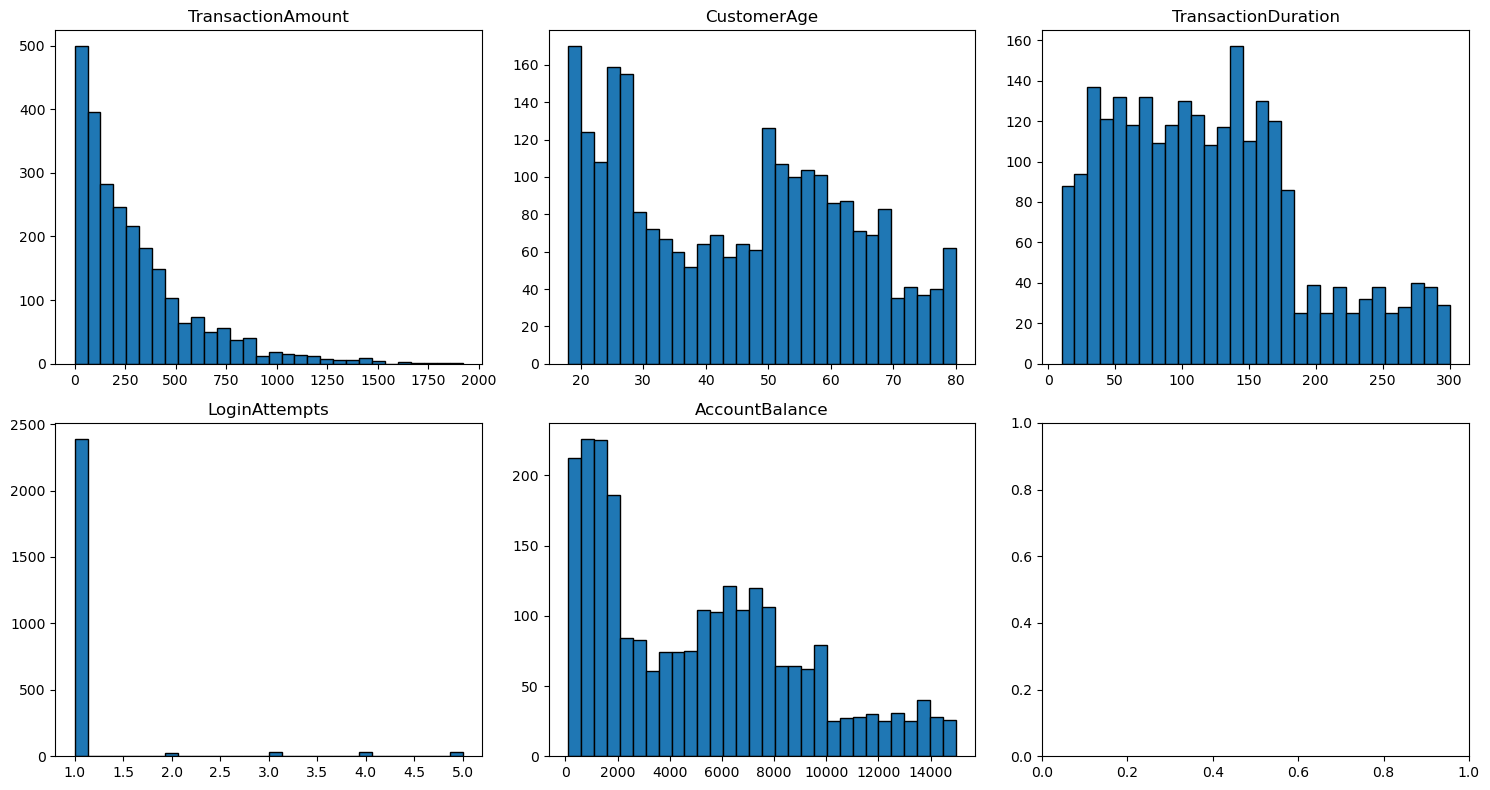

In [5]:
num_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("C:/Users/PAJEET/Documents/Jupyter codes/Portfolio works/Student Fintech Analyser/distributions.png")
plt.show

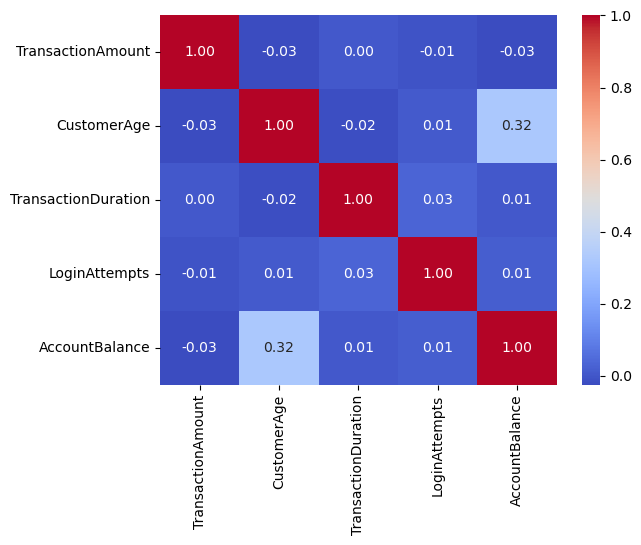

In [6]:
corr_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
df[corr_cols].corr()
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.savefig("C:/Users/PAJEET/Documents/Jupyter codes/Portfolio works/Student Fintech Analyser/correlation")

In [7]:
#Features are largely uncorrelated (all values near 0), except CustomerAge 
#and AccountBalance (0.32) — older customers hold higher balances. 
#No redundant features. All 5 will be used in clustering.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
df['TransactionType_enc'] = df['TransactionType'].map({'Debit': 0, 'Credit': 1})
df['Channel_enc'] = df['Channel'].map({'ATM': 0, 'Online': 1, 'Branch': 2})
features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TransactionType_enc', 'Channel_enc']
x = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
print("Shape:", X_scaled.shape)
print("Scaling done.")

Shape: (2512, 7)
Scaling done.


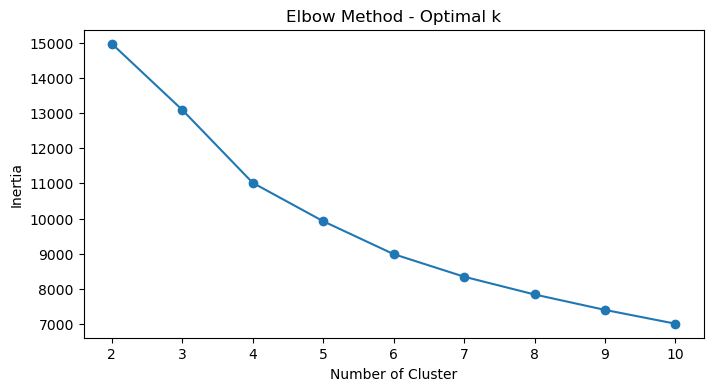

In [9]:
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method - Optimal k')
plt.xlabel('Number of Cluster')
plt.ylabel('Inertia')
plt.savefig('C:/Users/PAJEET/Documents/Jupyter codes/Portfolio works/Student Fintech Analyser/elbow.png')
plt.show()

In [10]:
#The elbow plot shows no sharp bend, which is typical of real transaction data. 
#K=4 is selected as the point where inertia reduction begins to diminish 
#significantly relative to added complexity.

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print("Cluster sizes: ")
print(df['Cluster'].value_counts().sort_index())

Cluster sizes: 
Cluster
0    1126
1     747
2     544
3      95
Name: count, dtype: int64


In [12]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary.to_string())

         TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  AccountBalance  TransactionType_enc  Channel_enc
Cluster                                                                                                                      
0                   277.01        55.42               120.02           1.01         6973.92                 0.00         0.90
1                   324.78        27.62               118.06           1.01         2171.42                 0.00         0.98
2                   306.59        45.87               118.89           1.01         5245.55                 1.00         1.31
3                   276.32        44.54               131.88           4.01         5461.64                 0.25         1.00


In [13]:
#Cluster 3 (95 transactions) is flagged as high-risk. Average LoginAttempts 
#of 4.01 vs 1.01 in all other clusters indicates repeated failed authentication 
#before a successful transaction — a primary indicator of account takeover or 
#brute-force fraud attempts.

#Cluster 0: Older, high-balance, debit-preferring — stable low-risk segment.
#Cluster 1: Young, low-balance, online-heavy — normal student/young adult behavior.
#Cluster 2: Middle-aged, credit-preferring, highest spend — active normal spenders.
#Cluster 3: Anomalous login behavior — fraud candidate segment.

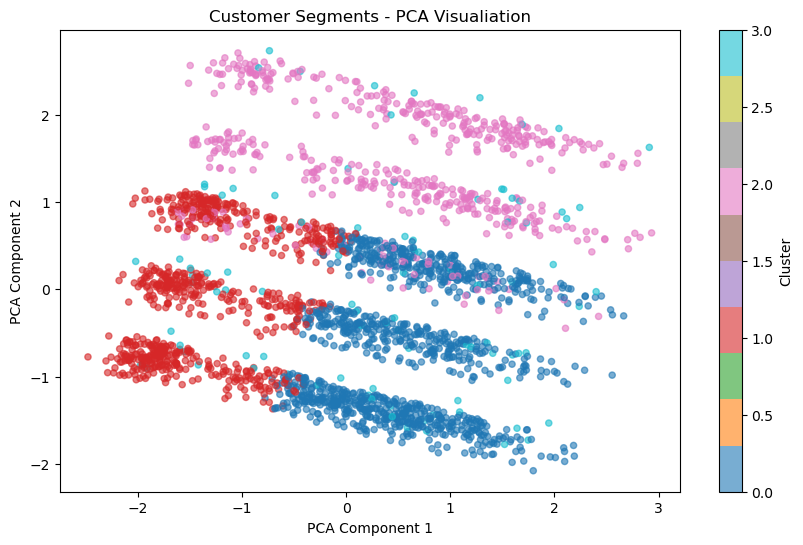

Variance explained by 2 component: 36.08%


In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Segments - PCA Visualiation')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.savefig("C:/Users/PAJEET/Documents/Jupyter codes/Portfolio works/Student Fintech Analyser/clusters_pca.png")
plt.show()
print(f"Variance explained by 2 component: {pca.explained_variance_ratio_.sum():.2%}")

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
df['HighRisk'] = (df['Cluster'] == 3).astype(int)
print("Class distribution: ")
print(df['HighRisk'].value_counts())
print(f"\nFraud rate: {df['HighRisk'].mean():.2%}")

Class distribution: 
HighRisk
0    2417
1      95
Name: count, dtype: int64

Fraud rate: 3.78%


In [16]:
X_clf = df[features]
y_clf = df['HighRisk']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Normal', 'High Risk']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       484
   High Risk       1.00      1.00      1.00        19

    accuracy                           1.00       503
   macro avg       1.00      1.00      1.00       503
weighted avg       1.00      1.00      1.00       503



In [17]:
#The classifier achieves 100% accuracy because the HighRisk label was derived 
#from the same features used for training. LoginAttempts is the dominant 
#separating feature for Cluster 3. In a production system, the classifier 
#would be trained on historical labeled fraud data rather than cluster-derived labels.
#This result confirms that Cluster 3 is a clean, well-separated segment — 
#not an artifact of noise.

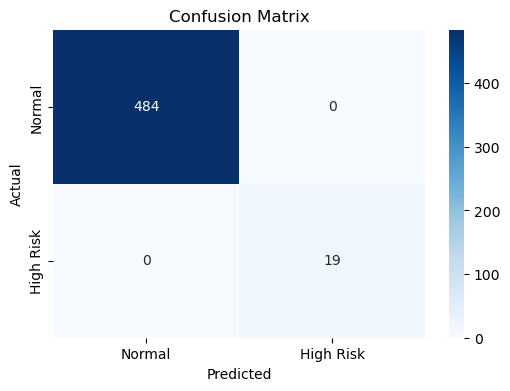

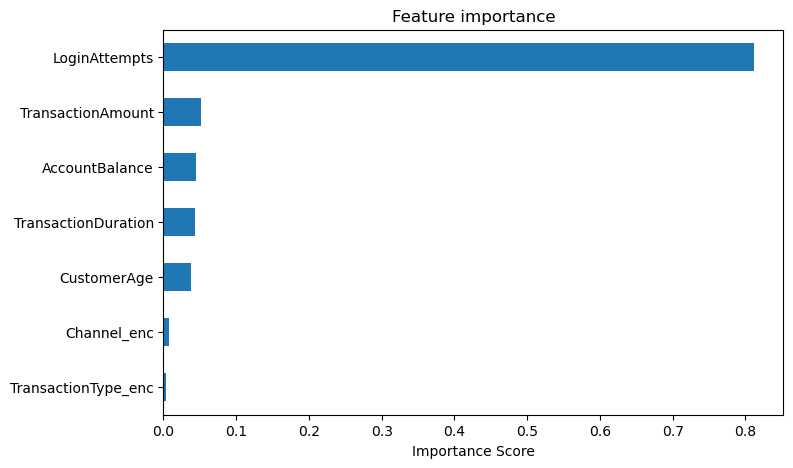

In [18]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Normal', 'High Risk'],
           yticklabels=['Normal', 'High Risk'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("C:/Users/PAJEET/Documents/Jupyter codes/Portfolio works/Student Fintech Analyser/confusion_matrix.png")
plt.show()

plt.figure(figsize=(8,5))
importances = pd.Series(clf.feature_importances_, index=features).sort_values()
importances.plot(kind='barh')
plt.title('Feature importance')
plt.xlabel('Importance Score')
plt.savefig("C:/Users/PAJEET/Documents/Jupyter codes/Portfolio works/Student Fintech Analyser/feature_importance.png")
plt.show()